### Note

Naming schema of regular reward manager and dapo reward manager differs.

for the regular reward manager we have '**val-core**/math-ai/math500/reward/mean@8' whereas

for the dapo manager we have '**val-aux**/math-ai/math500/reward/mean@8' metric.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
root_path = "/ptmp/rfechner/out/default/"
directories = list(
    filter(lambda x: x.startswith('dryrun'), os.listdir(root_path))
)
directories

['dryrun__qwen3_0.6b__gspo',
 'dryrun__qwen3_0.6b__dapo',
 'dryrun__llama_3.2_1b_instruct__drgrpo',
 'dryrun__llama_3.2_1b_instruct__gspo',
 'dryrun__llama_3.2_1b_instruct__grpo',
 'dryrun__qwen3_0.6b__drgrpo',
 'dryrun__qwen3_0.6b__grpo',
 'dryrun__llama_3.2_1b_instruct__dapo']

In [9]:
logs = {}
for dirname in directories:
    model, method = dirname.replace('dryrun__', '').split('__')
    path = os.path.join(root_path, dirname, 'logs.jsonl')
    with open(path, 'r') as file:
        tmp = pd.read_json(file, lines=True)
        logs[f"{model}_{method}"] = pd.DataFrame.from_dict(tmp['data'].to_list())
        

In [10]:
logs.keys()

dict_keys(['qwen3_0.6b_gspo', 'qwen3_0.6b_dapo', 'llama_3.2_1b_instruct_drgrpo', 'llama_3.2_1b_instruct_gspo', 'llama_3.2_1b_instruct_grpo', 'qwen3_0.6b_drgrpo', 'qwen3_0.6b_grpo', 'llama_3.2_1b_instruct_dapo'])

In [11]:
logs['llama_3.2_1b_instruct_dapo']

,global_seqlen/min,global_seqlen/max,global_seqlen/minmax_diff,global_seqlen/balanced_min,global_seqlen/balanced_max,global_seqlen/mean,actor/entropy,actor/pg_loss,actor/pg_clipfrac,actor/ppo_kl,...,timing_s/testing,timing_s/stop_profile,timing_per_token_ms/gen,timing_per_token_ms/update_actor,timing_per_token_ms/adv,perf/total_num_tokens,perf/time_per_step,perf/throughput,train/num_gen_batches,timing_s/save_checkpoint
0,335591,422114,86523,363878,363879,363878.250,3.519200,-0.000144,0.000086,-7.229093e-07,...,222.224938,0.000070,0.042967,0.031333,0.000053,2911026,222.228165,1637.408334,1,NaN
1,335595,439141,103546,386606,386606,386606.000,3.420008,0.000216,0.000076,-6.762043e-07,...,234.938328,0.000057,0.038579,0.030791,0.000045,3092848,224.230440,1724.145930,1,NaN
2,334835,419019,84184,371543,371544,371543.250,3.165765,0.000888,0.000253,7.211907e-05,...,241.750095,0.000060,0.042892,0.030687,0.000048,2972346,224.676707,1653.679437,1,NaN
3,329142,404447,75305,374029,374030,374029.125,3.012239,0.001648,0.000125,1.769783e-05,...,244.104278,0.000061,0.043070,0.030300,0.000047,2992233,225.087337,1661.706652,1,NaN
4,319492,391805,72313,350965,350966,350965.875,2.513061,0.000263,0.000612,1.462791e-04,...,227.144633,0.000073,0.040062,0.030368,0.000050,2807727,202.720838,1731.276754,1,2.022517
5,295226,407521,112295,345738,345739,345738.875,2.249680,0.000856,0.000268,1.133672e-04,...,227.195632,0.000058,0.039719,0.029935,0.000050,2765911,200.542406,1724.018786,1,NaN
6,310649,391699,81050,363704,363705,363704.625,1.897373,0.001597,0.000194,8.030573e-06,...,224.050098,0.000061,0.038063,0.029934,0.000054,2909637,205.410497,1770.623364,1,NaN
7,318030,421086,103056,359725,359726,359725.500,1.706922,0.001760,0.000156,5.406169e-05,...,227.093889,0.000065,0.045830,0.030416,0.000053,2877804,223.396017,1610.259238,1,NaN
8,310813,378090,67277,353294,353295,353294.375,1.537260,0.000984,0.000247,-3.418908e-05,...,234.789550,0.000075,0.042081,0.029695,0.000050,2826355,208.066185,1697.990354,1,NaN
9,320854,407051,86197,363624,363625,363624.750,1.388091,0.001306,0.000232,4.982725e-05,...,223.138868,0.000072,0.041895,0.029713,0.000049,2908998,213.849650,1700.375710,1,2.163284


In [42]:
set(filter(lambda x: 'val' in x,  logs['llama_3.2_1b_instruct_grpo'].columns))

{'val-aux/math-ai/math500/reward/best@2/mean',
 'val-aux/math-ai/math500/reward/best@2/std',
 'val-aux/math-ai/math500/reward/best@4/mean',
 'val-aux/math-ai/math500/reward/best@4/std',
 'val-aux/math-ai/math500/reward/std@8',
 'val-aux/math-ai/math500/reward/worst@2/mean',
 'val-aux/math-ai/math500/reward/worst@2/std',
 'val-aux/math-ai/math500/reward/worst@4/mean',
 'val-aux/math-ai/math500/reward/worst@4/std',
 'val-aux/math-ai/math500/reward/worst@8/mean',
 'val-aux/math-ai/math500/reward/worst@8/std',
 'val-core/math-ai/math500/reward/best@8/mean',
 'val-core/math-ai/math500/reward/best@8/std',
 'val-core/math-ai/math500/reward/mean@8'}

In [66]:
set(filter(lambda x: 'entropy' in x,  logs['qwen3_0.6b_grpo'].columns))

{'actor/entropy'}

Noted: deviation in naming schema for dapo reward manager. Implies considerations on whether to change regular reward manager to dapo reward manager.

In [67]:
method2name = {
    'reward' : {
        'dapo' : 'val-core/math-ai/math500/acc/mean@8',
        'gspo' : 'val-core/math-ai/math500/acc/mean@8',
        'grpo' : 'val-core/math-ai/math500/reward/mean@8',
        'drgrpo' : 'val-core/math-ai/math500/reward/mean@8'
    },
    'policy gradient loss' : {
        'dapo' : 'actor/pg_loss',
        'gspo' : 'actor/pg_loss',
        'grpo' : 'actor/pg_loss',
        'drgrpo' : 'actor/pg_loss'
    },
    'entropy' : {
        'dapo' : 'actor/entropy',
        'gspo' : 'actor/entropy',
        'grpo' : 'actor/entropy',
        'drgrpo' : 'actor/entropy'
    }
}

In [91]:
from typing import Literal
def plot(key : Literal['reward', 'policy gradient loss', 'entropy'] = 'reward', without_method:list[str]=[], without_model:list[str]=[]):

    fig, ax = plt.subplots(1, 1, figsize=(10, 5))
    for method in logs.keys():
        true_method = method.split('_')[-1]
        model = '_'.join(method.split('_')[:-1])
        if (without_method and true_method in without_method) or \
            (without_model and model in without_model):
            continue
        true_key = method2name[key][true_method]
        try:
            values = logs[method][true_key]
            ax.plot(values, label=method)
        except KeyError:
            print(f"Couldn't find key: {key} for method {method}")
            continue
        
    plt.xlabel("Steps")
    plt.ylabel(f"{key}")
    plt.legend()
    plt.show()

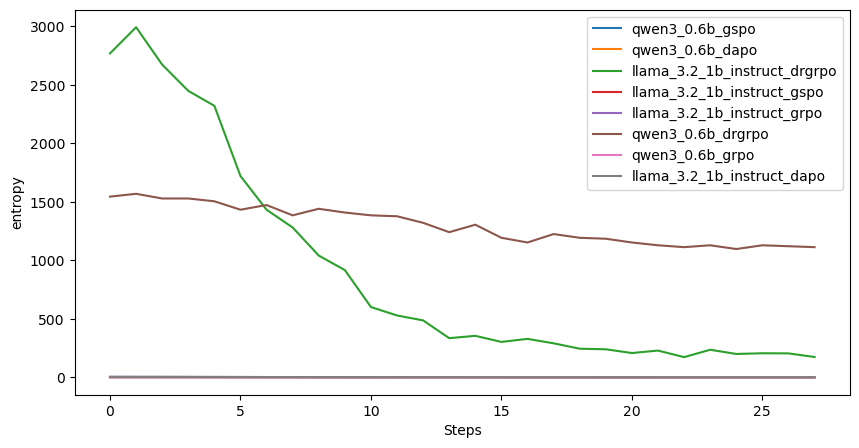

In [92]:
plot('entropy', without_method=[''], without_model=[''])